# Trader Performance and Bitcoin Market Sentiment Analysis

This notebook is my analysis of how trader performance changes during different Bitcoin market sentiment phases like Fear, Greed, Extreme Fear and Extreme Greed.

I have kept the code simple and readable. The main goal is to clean the data, merge both datasets using date, calculate useful metrics, create visualizations, and write practical insights from the results.

## What I am trying to find

In this analysis, I am checking:

- Which sentiment gives better average PnL
- Whether traders perform better during Fear or Greed
- Which traders are the best and worst performers
- Whether risk-taking changes with sentiment
- What happens during Extreme Fear and Extreme Greed
- Whether the difference between Extreme Fear and Extreme Greed looks statistically meaningful

## 1. Import Libraries

In [ ]:
# Basic data analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import erf, sqrt
from pathlib import Path
sns.set_theme(style="whitegrid")

# Show more columns while displaying dataframes
pd.set_option("display.max_columns", 50)

## 2. Load the Datasets

In [ ]:
#G-drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Load CSV files
fear_greed = pd.read_csv('/content/drive/MyDrive/Assignment/DataSet/fear_greed_index.csv')
trades = pd.read_csv('/content/drive/MyDrive/Assignment/DataSet/historical_data.csv')

print("Fear & Greed data shape:", fear_greed.shape)
print("Historical trades data shape:", trades.shape)

# Display first few rows
fear_greed.head(), trades.head()

Fear & Greed data shape: (2644, 4)
Historical trades data shape: (211224, 16)


(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

## 3. Basic Data Cleaning

In [ ]:
# Make column names simple and easy to use (LowerCase)
# Example: "Closed PnL" becomes "closed_pnl"
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

fear_greed = clean_column_names(fear_greed)
trades = clean_column_names(trades)

print(fear_greed.columns.tolist())
print(trades.columns.tolist())

['timestamp', 'value', 'classification', 'date']
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


## 4. Convert Dates

In [ ]:
# Convert sentiment date column to datetime
fear_greed["date"] = pd.to_datetime(fear_greed["date"], errors="coerce")
trades["trade_time"] = pd.to_datetime(
    trades["timestamp_ist"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Create a common date column for merging both datasets
trades["date"] = trades["trade_time"].dt.date
fear_greed["date"] = fear_greed["date"].dt.date

print("Trade date range:", trades["date"].min(), "to", trades["date"].max())
print("Sentiment date range:", fear_greed["date"].min(), "to", fear_greed["date"].max())

Trade date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


## 5. Prepare Useful Columns

In [ ]:
# Convert important numeric columns safely
numeric_cols = ["execution_price", "size_tokens", "size_usd", "start_position", "closed_pnl", "fee"]

for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

trades["is_win"] = trades["closed_pnl"] > 0
trades["is_loss"] = trades["closed_pnl"] < 0

# Net PnL after fee
trades["net_pnl"] = trades["closed_pnl"] - trades["fee"]

trades["abs_start_position"] = trades["start_position"].abs()

trades.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_time,date,is_win,is_loss,net_pnl,abs_start_position
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,False,False,-0.345404,0.000000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,False,False,-0.005600,986.524596
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,False,False,-0.050431,1002.518996
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,False,False,-0.050043,1146.558564
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,False,False,-0.003055,1289.488521


## 6. Merge Trader Data with Sentiment Data

In [ ]:
# Keep only required sentiment columns
sentiment_data = fear_greed[["date", "value", "classification"]].copy()
sentiment_data = sentiment_data.rename(columns={"value": "fear_greed_value"})

# Merge trades with sentiment using date
merged = trades.merge(sentiment_data, on="date", how="left")

# Remove rows where sentiment is missing
merged = merged.dropna(subset=["classification"])

print("Merged data shape:", merged.shape)
merged[["account", "coin", "date", "closed_pnl", "classification", "fear_greed_value"]].head()

Merged data shape: (211218, 24)


,account,coin,date,closed_pnl,classification,fear_greed_value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,Extreme Greed,80.0


## 7. Simple EDA

In [ ]:
print("Total matched trades:", len(merged))
print("Number of traders:", merged["account"].nunique())
print("Number of coins traded:", merged["coin"].nunique())
print("Total Closed PnL:", round(merged["closed_pnl"].sum(), 2))
print("Average Closed PnL:", round(merged["closed_pnl"].mean(), 2))
print("Overall win rate:", round(merged["is_win"].mean() * 100, 2), "%")

# Sentiment distribution
merged["classification"].value_counts()

Total matched trades: 211218
Number of traders: 32
Number of coins traded: 246
Total Closed PnL: 10254486.95
Average Closed PnL: 48.55
Overall win rate: 41.12 %


,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


### Important observation

Many rows have `closed_pnl = 0`. This usually means the row may be an opening trade, position adjustment, or a trade where PnL was not realized yet.

So I will calculate normal metrics using all rows, but I will also check realized rows separately where `closed_pnl != 0`.

In [ ]:
zero_pnl_share = (merged["closed_pnl"] == 0).mean() * 100
print("Rows with zero Closed PnL:", round(zero_pnl_share, 2), "%")

realized_trades = merged[merged["closed_pnl"] != 0].copy()
print("Realized PnL rows:", realized_trades.shape)

Rows with zero Closed PnL: 50.57 %
Realized PnL rows: (104402, 24)


## 8. Main Metrics by Sentiment

In [ ]:
# Metrics requested in the task
sentiment_metrics = (
    merged.groupby("classification")
    .agg(
        trade_count=("closed_pnl", "count"),
        total_pnl=("closed_pnl", "sum"),
        average_pnl=("closed_pnl", "mean"),
        win_rate=("is_win", "mean"),
        average_trade_size_usd=("size_usd", "mean"),
        average_fee=("fee", "mean")
    )
    .reset_index()
)

# Convert win rate into percentage
sentiment_metrics["win_rate"] = sentiment_metrics["win_rate"] * 100

# Sort in a logical order
sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
sentiment_metrics["classification"] = pd.Categorical(
    sentiment_metrics["classification"],
    categories=sentiment_order,
    ordered=True
)
sentiment_metrics = sentiment_metrics.sort_values("classification")

sentiment_metrics

,classification,trade_count,total_pnl,average_pnl,win_rate,average_trade_size_usd,average_fee
0,Extreme Fear,21400,7.391102e+05,34.537862,37.060748,5349.731843,1.116291
2,Fear,61837,3.357155e+06,54.290400,42.076750,7816.109931,1.495172
4,Neutral,37686,1.292921e+06,34.307718,39.699093,4782.732661,1.044798
3,Greed,50303,2.150129e+06,42.743559,38.482794,5736.884375,1.254372
1,Extreme Greed,39992,2.715171e+06,67.892861,46.494299,3112.251565,0.675902


## 9. Realized PnL Metrics by Sentiment

In [ ]:
# These metrics ignore zero PnL rows
# This gives a better idea of actual profitable/loss-making closed trades
realized_metrics = (
    realized_trades.groupby("classification")
    .agg(
        realized_trade_count=("closed_pnl", "count"),
        average_realized_pnl=("closed_pnl", "mean"),
        median_realized_pnl=("closed_pnl", "median"),
        realized_win_rate=("closed_pnl", lambda x: (x > 0).mean() * 100),
        pnl_5th_percentile=("closed_pnl", lambda x: x.quantile(0.05)),
        pnl_1st_percentile=("closed_pnl", lambda x: x.quantile(0.01))
    )
    .reset_index()
)

realized_metrics["classification"] = pd.Categorical(
    realized_metrics["classification"],
    categories=sentiment_order,
    ordered=True
)
realized_metrics = realized_metrics.sort_values("classification")

realized_metrics

,classification,realized_trade_count,average_realized_pnl,median_realized_pnl,realized_win_rate,pnl_5th_percentile,pnl_1st_percentile
0,Extreme Fear,10406,71.027316,6.388050,76.215645,-198.699782,-1211.739891
2,Fear,29808,112.625988,6.350483,87.288647,-17.780043,-236.604309
4,Neutral,18159,71.199993,4.583458,82.388898,-27.326341,-359.881575
3,Greed,25176,85.403927,4.927600,76.890690,-37.758869,-417.600858
1,Extreme Greed,20853,130.205309,8.530740,89.167026,-5.843052,-135.434840


## 10. Top and Bottom Traders

In [ ]:
trader_metrics = (
    merged.groupby("account")
    .agg(
        trade_count=("closed_pnl", "count"),
        total_pnl=("closed_pnl", "sum"),
        average_pnl=("closed_pnl", "mean"),
        win_rate=("is_win", "mean"),
        active_days=("date", "nunique"),
        average_trade_size_usd=("size_usd", "mean")
    )
    .reset_index()
)

trader_metrics["win_rate"] = trader_metrics["win_rate"] * 100

# Top 10 traders by total PnL
top_traders = trader_metrics.sort_values("total_pnl", ascending=False).head(10)

# Bottom 10 traders by total PnL
bottom_traders = trader_metrics.sort_values("total_pnl", ascending=True).head(10)

print("Top Traders")
display(top_traders)

print("Bottom Traders")
display(bottom_traders)

Top Traders


,account,trade_count,total_pnl,average_pnl,win_rate,active_days,average_trade_size_usd
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.481748,33.713432,256,3837.885375
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236,24,16159.576734
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.364091,46.758211,28,3210.472831
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.684419,40.119320,39,34396.580284
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.806305,42.823014,131,1844.211886
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,6.777471e+05,155.589314,48.622590,58,9084.699093
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,4.293556e+05,270.034947,34.591195,19,7216.667245
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,336.735548,48.423605,28,2397.824753
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,38.319560,81.087638,146,2600.778049
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,3.605395e+05,253.187858,30.337079,65,2080.390077


Bottom Traders


,account,trade_count,total_pnl,average_pnl,win_rate,active_days,average_trade_size_usd
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,4601,-167621.124781,-36.431455,38.274288,92,2204.685531
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-70436.191318,-18.492043,30.191651,12,8893.000898
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,-31203.599986,-38.286626,45.521472,43,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,14456.919336,4.028119,32.766787,46,4790.575486
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,1559,14900.443047,9.557693,45.221296,26,3748.867511
26,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,534,21758.831753,40.746876,32.209738,20,8330.193371
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,4838,22488.500821,4.648305,43.861100,35,22504.555829
21,0x8477e447846c758f5a675856001ea72298fd9cb5,14998,43917.008976,2.928191,26.196826,174,820.428513
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,47885.320514,6.577654,44.271978,52,1653.226327
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,53496.247243,161.133275,47.590361,28,3445.471265


## 11. Trader Consistency

In [ ]:
# Daily PnL helps us understand consistency better than only total PnL
# A trader can have high total profit but still be very inconsistent.

daily_trader_pnl = (
    merged.groupby(["account", "date"])
    .agg(daily_pnl=("closed_pnl", "sum"))
    .reset_index()
)

consistency = (
    daily_trader_pnl.groupby("account")
    .agg(
        active_days=("date", "count"),
        total_pnl=("daily_pnl", "sum"),
        avg_daily_pnl=("daily_pnl", "mean"),
        std_daily_pnl=("daily_pnl", "std"),
        positive_day_rate=("daily_pnl", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

# Simple Sharpe-like score. This is not a perfect Sharpe ratio, just a consistency proxy.
consistency["sharpe_proxy"] = consistency["avg_daily_pnl"] / consistency["std_daily_pnl"]

# Showing traders with at least 20 active days to avoid very small samples
consistent_traders = consistency[
    (consistency["active_days"] >= 20) &
    (consistency["total_pnl"] > 0)
].sort_values("sharpe_proxy", ascending=False)

consistent_traders.head(10)

,account,active_days,total_pnl,avg_daily_pnl,std_daily_pnl,positive_day_rate,sharpe_proxy
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,26,14900.443047,573.093963,873.410811,61.538462,0.656156
23,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,64,106302.875256,1660.982426,2678.372531,71.875000,0.620146
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,146,379095.406711,2596.543882,4762.374294,91.095890,0.545220
26,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,20,21758.831753,1087.941588,2029.269543,55.000000,0.536125
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,39,840422.555216,21549.296288,42171.744699,56.410256,0.510989
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,69,168658.004994,2444.318913,4867.743469,78.260870,0.502146
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,20,199505.592732,9975.279637,20797.396045,50.000000,0.479641
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,58,677747.050643,11685.293977,25344.268485,67.241379,0.461063
9,0x430f09841d65beb3f27765503d0f850b8bce7713,28,416541.872341,14876.495441,32725.083260,25.000000,0.454590
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,28,940163.806220,33577.278794,74757.661015,78.571429,0.449148


## 12. Fear vs Greed Comparison

In [ ]:
# Combine Extreme Fear + Fear as "Fear"
# Combine Greed + Extreme Greed as "Greed"

def sentiment_group(x):
    if x in ["Extreme Fear", "Fear"]:
        return "Fear"
    elif x in ["Greed", "Extreme Greed"]:
        return "Greed"
    else:
        return "Neutral"

merged["sentiment_group"] = merged["classification"].apply(sentiment_group)

fear_greed_compare = (
    merged[merged["sentiment_group"].isin(["Fear", "Greed"])]
    .groupby("sentiment_group")
    .agg(
        trade_count=("closed_pnl", "count"),
        total_pnl=("closed_pnl", "sum"),
        average_pnl=("closed_pnl", "mean"),
        win_rate=("is_win", "mean"),
        average_trade_size_usd=("size_usd", "mean"),
        average_abs_start_position=("abs_start_position", "mean")
    )
    .reset_index()
)

fear_greed_compare["win_rate"] = fear_greed_compare["win_rate"] * 100
fear_greed_compare

,sentiment_group,trade_count,total_pnl,average_pnl,win_rate,average_trade_size_usd,average_abs_start_position
0,Fear,83237,4.096266e+06,49.212077,40.78715,7182.011019,77446.576363
1,Greed,90295,4.865301e+06,53.882281,42.03112,4574.424490,134402.549889


## 13. Extreme Fear vs Extreme Greed

In [ ]:
extreme_compare = merged[merged["classification"].isin(["Extreme Fear", "Extreme Greed"])]

extreme_summary = (
    extreme_compare.groupby("classification")
    .agg(
        trade_count=("closed_pnl", "count"),
        total_pnl=("closed_pnl", "sum"),
        average_pnl=("closed_pnl", "mean"),
        win_rate=("is_win", "mean"),
        average_trade_size_usd=("size_usd", "mean")
    )
    .reset_index()
)

extreme_summary["win_rate"] = extreme_summary["win_rate"] * 100
extreme_summary

,classification,trade_count,total_pnl,average_pnl,win_rate,average_trade_size_usd
0,Extreme Fear,21400,7.391102e+05,34.537862,37.060748,5349.731843
1,Extreme Greed,39992,2.715171e+06,67.892861,46.494299,3112.251565


## 14. Simple Statistical Significance Check

In [ ]:
# I am doing a simple Welch-style test manually.
# This checks whether average PnL in Extreme Greed is different from Extreme Fear.
# Since the sample size is large, this approximation is acceptable for a simple internship project.

extreme_fear_pnl = merged.loc[merged["classification"] == "Extreme Fear", "closed_pnl"].dropna()
extreme_greed_pnl = merged.loc[merged["classification"] == "Extreme Greed", "closed_pnl"].dropna()

mean_diff = extreme_greed_pnl.mean() - extreme_fear_pnl.mean()

standard_error = np.sqrt(
    extreme_greed_pnl.var(ddof=1) / len(extreme_greed_pnl) +
    extreme_fear_pnl.var(ddof=1) / len(extreme_fear_pnl)
)

z_score = mean_diff / standard_error

# Two-sided p-value using normal approximation
p_value = 2 * (1 - 0.5 * (1 + erf(abs(z_score) / sqrt(2))))

print("Average PnL difference (Extreme Greed - Extreme Fear):", round(mean_diff, 2))
print("Z-score:", round(z_score, 3))
print("Approx p-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: The difference looks statistically significant.")
else:
    print("Result: The difference is not statistically significant.")

Average PnL difference (Extreme Greed - Extreme Fear): 33.35
Z-score: 3.851
Approx p-value: 0.000118
Result: The difference looks statistically significant.


## 15. Visualizations

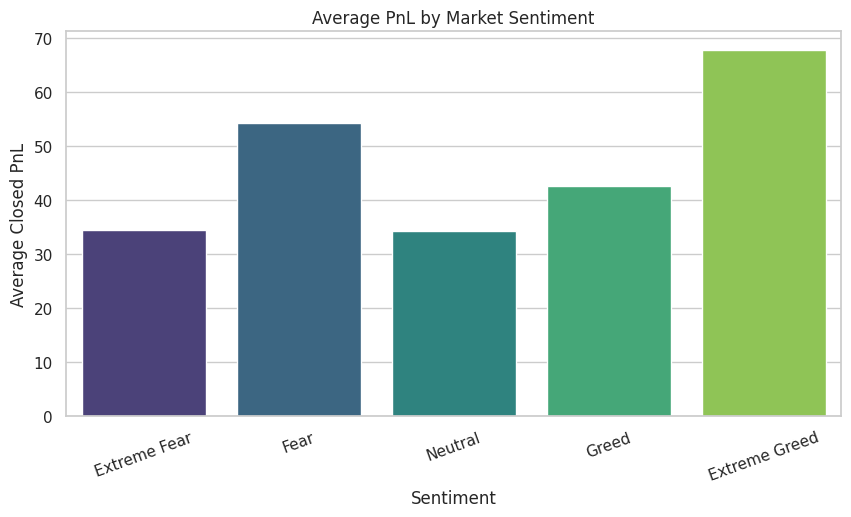

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_metrics, x="classification", y="average_pnl", hue="classification", palette="viridis", legend=False)
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=20)
plt.show()

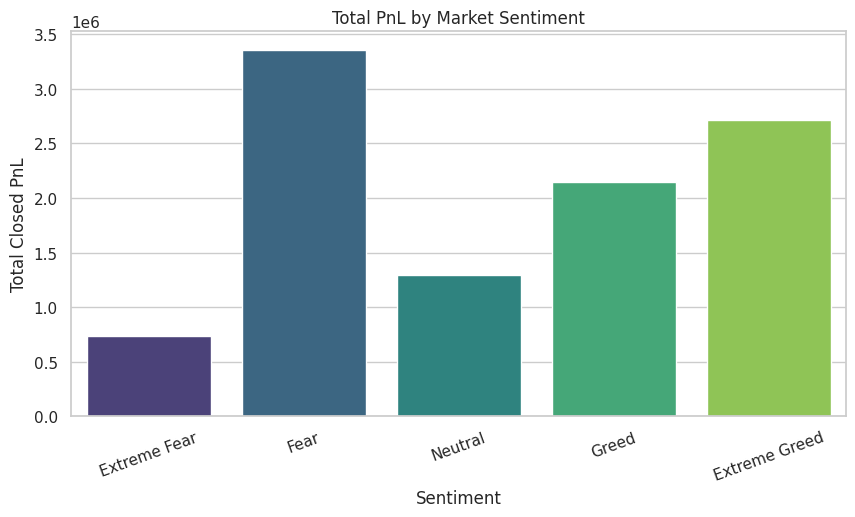

In [ ]:
# Bar chart: Total PnL by sentiment
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_metrics, x="classification", y="total_pnl", hue="classification", palette="viridis", legend=False)
plt.title("Total PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=20)
plt.show()

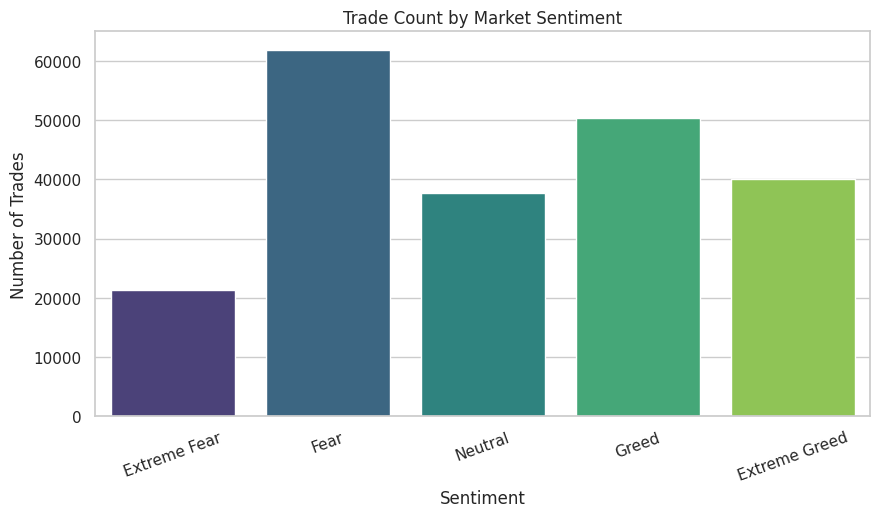

In [ ]:
# Bar chart: Trade count by sentiment
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_metrics, x="classification", y="trade_count", hue="classification", palette="viridis", legend=False)
plt.title("Trade Count by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)
plt.show()

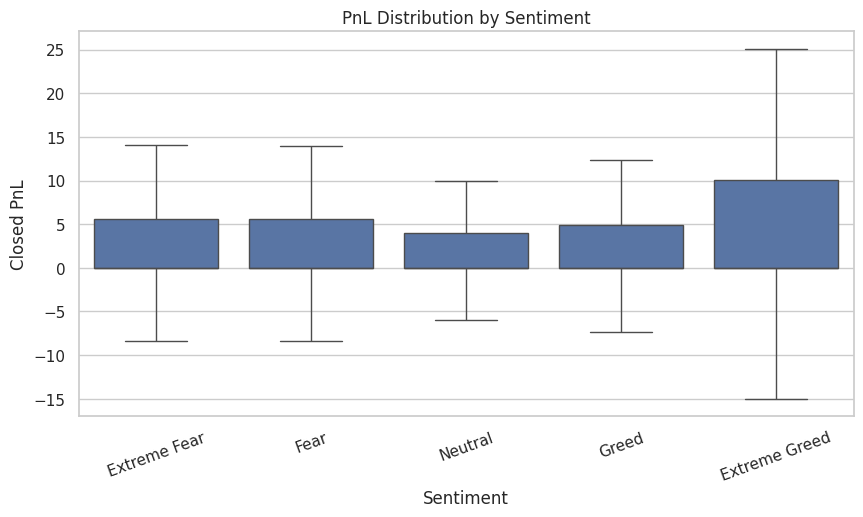

In [ ]:
# Box plot: PnL distribution by sentiment
# I hide outliers because PnL has some very large values, which makes the boxplot hard to read.
plt.figure(figsize=(10, 5))
sns.boxplot(data=merged, x="classification", y="closed_pnl", order=sentiment_order, showfliers=False)
plt.title("PnL Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=20)
plt.show()

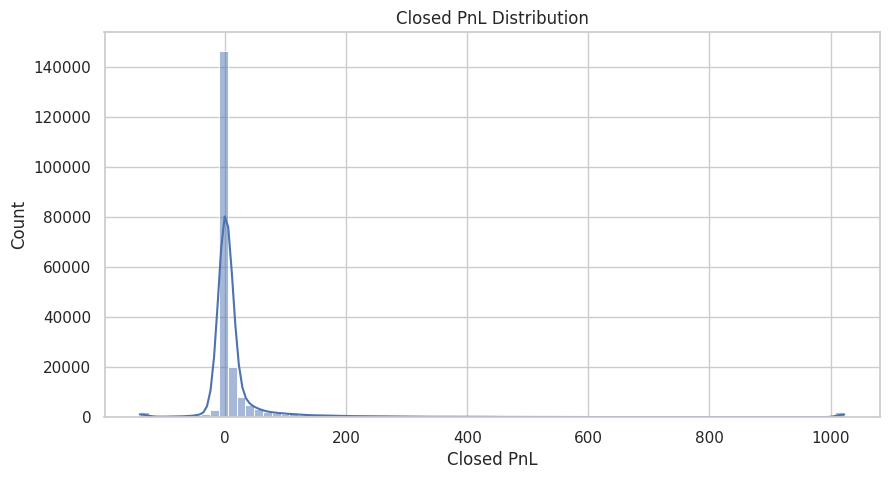

In [ ]:
# Histogram: PnL distribution
# Clipping extreme values makes the central distribution easier to see.
plt.figure(figsize=(10, 5))
clipped_pnl = merged["closed_pnl"].clip(
    lower=merged["closed_pnl"].quantile(0.01),
    upper=merged["closed_pnl"].quantile(0.99)
)
sns.histplot(clipped_pnl, bins=80, kde=True)
plt.title("Closed PnL Distribution")
plt.xlabel("Closed PnL")
plt.show()

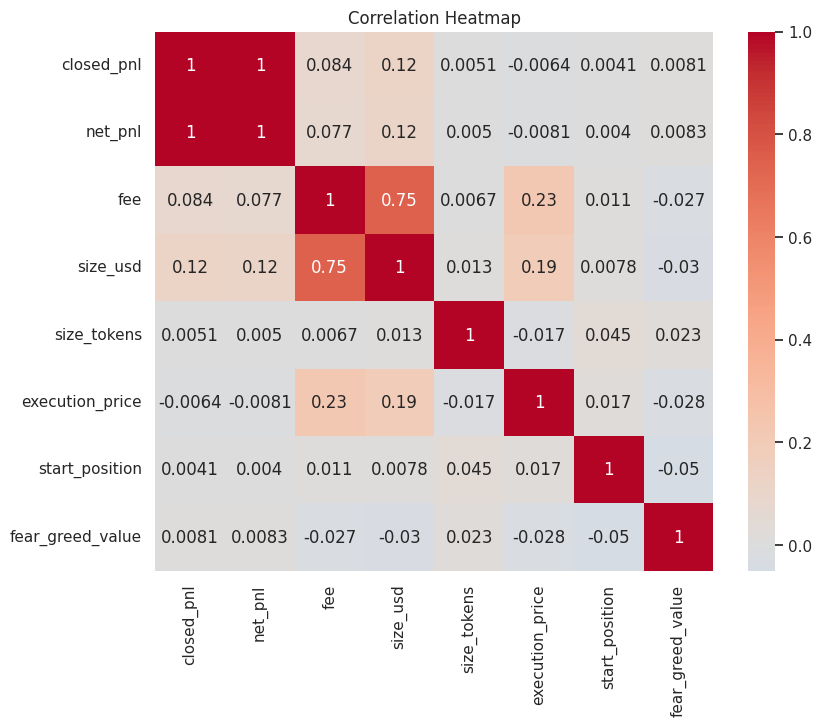

In [ ]:
# Correlation heatmap for numeric columns
corr_cols = [
    "closed_pnl",
    "net_pnl",
    "fee",
    "size_usd",
    "size_tokens",
    "execution_price",
    "start_position",
    "fear_greed_value"
]

plt.figure(figsize=(9, 7))
sns.heatmap(merged[corr_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 16. Final Insights

In [ ]:
print("Key Insights from the Analysis")
print("--------------------------------")

best_sentiment = sentiment_metrics.sort_values("average_pnl", ascending=False).iloc[0]
worst_sentiment = sentiment_metrics.sort_values("average_pnl", ascending=True).iloc[0]

print(f"1. Best average PnL is during {best_sentiment['classification']} with average PnL of {best_sentiment['average_pnl']:.2f}.")
print(f"2. Worst average PnL is during {worst_sentiment['classification']} with average PnL of {worst_sentiment['average_pnl']:.2f}.")

print("3. A lot of trades have zero Closed PnL, so realized PnL rows should be checked separately.")
print("4. Extreme Greed has better realized win rate and better average realized PnL than Extreme Fear.")
print("5. Extreme Fear has bigger downside risk based on 1st and 5th percentile PnL.")
print("6. Fear periods have larger average trade size, which suggests more risk-taking during fearful markets.")
print("7. The dataset does not contain leverage, so I used trade size and starting position as risk proxies.")
print("8. Trader performance is not equal. Some traders are consistent, while others depend more on specific market regimes.")
print("9. Sentiment value has weak direct correlation with PnL, so the relationship is not simply linear.")
print("10. Overall, market sentiment seems useful for understanding trader behavior, especially when comparing Extreme Fear and Extreme Greed.")

Key Insights from the Analysis
--------------------------------
1. Best average PnL is during Extreme Greed with average PnL of 67.89.
2. Worst average PnL is during Neutral with average PnL of 34.31.
3. A lot of trades have zero Closed PnL, so realized PnL rows should be checked separately.
4. Extreme Greed has better realized win rate and better average realized PnL than Extreme Fear.
5. Extreme Fear has bigger downside risk based on 1st and 5th percentile PnL.
6. Fear periods have larger average trade size, which suggests more risk-taking during fearful markets.
7. The dataset does not contain leverage, so I used trade size and starting position as risk proxies.
8. Trader performance is not equal. Some traders are consistent, while others depend more on specific market regimes.
9. Sentiment value has weak direct correlation with PnL, so the relationship is not simply linear.
10. Overall, market sentiment seems useful for understanding trader behavior, especially when comparing Extre

## Conclusion

From this analysis, I found that trader performance changes across Bitcoin sentiment regimes. Extreme Greed appears to be the strongest condition for average and realized PnL, while Extreme Fear has higher downside risk.

One important learning from this dataset is that we should not blindly use all rows for win rate because many rows have zero PnL. Looking at realized PnL gives a clearer picture.

Also, actual leverage was not available in the dataset, so I did not make up leverage numbers. Instead, I used trade size and starting position as simple risk-taking indicators.

## 17. Detailed Report using Pandas Profiling

In [ ]:
# Install pandas-profiling
!pip install ydata-profiling

In [35]:
# Import ProfileReport
from ydata_profiling import ProfileReport
profile = ProfileReport(merged, title="Bitcoin Trader Performance and Sentiment Report")

# Display the report directly in the notebook
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

In [40]:
# Save the report to an HTML file for download
report_path = "bitcoin_trader_report.html"
profile.to_file('/content/drive/MyDrive/Primetrade-Assignment/bitcoin_trader_report.html')
print(f"Profiling report saved to {report_path}. You can download it from the file browser.")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report saved to bitcoin_trader_report.html. You can download it from the file browser.


The report above provides an extensive overview of your dataset, including statistics, distributions, correlations, and missing values. You can interact with it to explore the data in more detail.